In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
from spatial_manifolds.anaylsis_parameters import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline


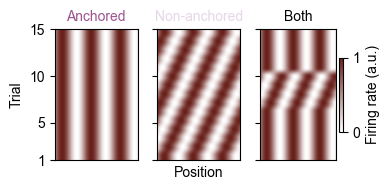

In [2]:
# --- Composite plot: Anchored, Non-anchored, and hybrid sequence ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import find_peaks

# Parameters
track_length = 200  # cm
n_trials = 15
n_bins = 400
period = 70  # grid spacing in cm
trial_positions = np.linspace(0, track_length, n_bins)

# Colors
col_ta = "#9d5391"   # Task-anchored
col_nta = "#e7d7e8"  # Non-task-anchored
black_cmap = LinearSegmentedColormap.from_list('black_cmap', ['white', gc_color_dark])

# Task-anchored
ta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    ta_map[t] = np.sin(2 * np.pi * trial_positions / period)
ta_map = (ta_map - ta_map.min()) / (ta_map.max() - ta_map.min())

# Non-task-anchored
nta_map = np.zeros((n_trials, n_bins))
for t in range(n_trials):
    nta_map[t] = np.sin(2 * np.pi * (trial_positions + t * track_length) / period)
nta_map = (nta_map - nta_map.min()) / (nta_map.max() - nta_map.min())

# Hybrid: 5 anchored, 5 non-anchored, 5 anchored (total 15 trials)
hybrid_trials = 15
hybrid_map = np.zeros((hybrid_trials, n_bins))
for t in range(5):
    hybrid_map[t] = np.sin(2 * np.pi * trial_positions / period)  # anchored
for t in range(5, 10):
    hybrid_map[t] = np.sin(2 * np.pi * (trial_positions + (t-5) * track_length) / period)  # non-anchored
for t in range(10, 15):
    hybrid_map[t] = np.sin(2 * np.pi * trial_positions / period)  # anchored
hybrid_map = (hybrid_map - hybrid_map.min()) / (hybrid_map.max() - hybrid_map.min())

# Plot
fig, axes = plt.subplots(1, 3, figsize=(4, 2), sharey=True)

# Task-anchored (left)
im0 = axes[0].imshow(ta_map, aspect='auto', cmap=black_cmap,
                    vmin=0, vmax=1, origin='lower',
                    extent=[0, track_length, 1, n_trials])
axes[0].set_title('Anchored', color=col_ta, fontsize=10)
axes[0].set_ylabel('Trial')
axes[0].set_xticks([])
axes[0].set_yticks([1, 5, 10, 15])
'''# Add vertical lines at firing field peaks
peaks, _ = find_peaks(ta_map[0], height=0.7)
peak_positions = trial_positions[peaks]
for xpos in peak_positions:
    axes[0].axvline(xpos, color=col_ta, lw=2, alpha=0.9, zorder=10)
'''
# Non-task-anchored (middle)
im1 = axes[1].imshow(nta_map, aspect='auto', cmap=black_cmap,
                    vmin=0, vmax=1, origin='lower',
                    extent=[0, track_length, 1, n_trials])
axes[1].set_title('Non-anchored', color=col_nta, fontsize=10)
axes[1].set_xlabel('Position')
axes[1].set_xticks([])
axes[1].set_yticks([1, 5, 10, 15])

# Hybrid (right)
im2 = axes[2].imshow(hybrid_map, aspect='auto', cmap=black_cmap,
                    vmin=0, vmax=1, origin='lower',
                    extent=[0, track_length, 1, hybrid_trials])
axes[2].set_title('Both', fontsize=10)
axes[2].set_xticks([])
axes[2].set_yticks([1, 5, 10, 15])
'''# Add vertical lines at firing field peaks only within the anchored trials
peaks, _ = find_peaks(hybrid_map[0], height=0.7)
peak_positions = trial_positions[peaks]
for xpos in peak_positions:
    axes[2].axvline(xpos, color=col_ta, lw=2, alpha=0.9, zorder=10, ymin=0, ymax=5/hybrid_trials)
peaks_end, _ = find_peaks(hybrid_map[-1], height=0.7)
peak_positions_end = trial_positions[peaks_end]
for xpos in peak_positions_end:
    axes[2].axvline(xpos, color=col_ta, lw=2, alpha=0.9, zorder=10, ymin=10/hybrid_trials, ymax=15/hybrid_trials)
'''
# Colorbar for the rightmost plot
cbar2 = fig.colorbar(im2, ax=axes[2], fraction=0.045, pad=0.04)
cbar2.set_ticks([0,1])
cbar2.set_label('Firing rate (a.u.)')

plt.tight_layout()
plt.savefig('task_anchoring_schematic.pdf', dpi=300)
plt.show()


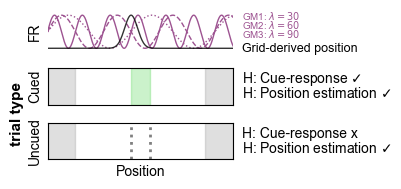

In [3]:
# --- Grid cells and track cues: 3-row plot with annotations ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

track_length = 200
x = np.linspace(0, track_length, 400)
periods = [30, 60, 90]
alphas = [0.9, 0.6, 0.3]
colors = ['#9d5391', '#9d5391', '#9d5391']
thickness = [1,1,1]

fig, axes = plt.subplots(3, 1, figsize=(4, 2), sharex=True, gridspec_kw={'height_ratios': [0.7, 0.7, 0.7]})

# Row 1: grid cell firing rates
linestyles = ['-', '--', ':']
for i, (p, c, t, a, ls) in enumerate(zip(periods, colors, thickness, alphas, linestyles)):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    axes[0].plot(x, y, label=f'Period {p} cm', color=c, lw=t, ls=ls)

# Add Gaussian (black) centered at 90
mu = 90
sigma = 7
G = norm.pdf(x, mu, sigma)
G = G / G.max()  # normalize to 1
axes[0].plot(x, G, color='black', lw=1, alpha=0.8, label='Gaussian @ 90')

axes[0].set_xlim(0, 200)
axes[0].set_yticks([])
axes[0].set_xticks([])
axes[0].set_ylabel('FR')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)

# Manual legend using axes[0].text
axes[0].text(1.05, 1.1, r'GM1: $\lambda=30$', color=colors[0], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.85, r'GM2: $\lambda=60$', color=colors[1], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.6, r'GM3: $\lambda=90$', color=colors[2], fontsize=7, alpha=1, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.2, r'Grid-derived position', color='black', fontsize=9, transform=axes[0].transAxes, va='top')

# Row 2: cued track (reward zone)
axes[1].fill_betweenx([0, 1], 90, 110, color='limegreen', alpha=0.25, zorder=0)
axes[1].fill_betweenx([0, 1], 0, 30, color='grey', alpha=0.25, zorder=0)
axes[1].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[1].set_xlim(0, 200)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_ylabel('Cued')

# Row 3: non-cued track (dotted lines)
axes[2].axvline(90, color='grey', ls=':', lw=2)
axes[2].axvline(110, color='grey', ls=':', lw=2)
axes[2].fill_betweenx([0, 1], 0, 30, color='grey', alpha=0.25, zorder=0)
axes[2].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[2].set_xlim(0, 200)
axes[2].set_ylim(0, 1)
axes[2].set_yticks([])
axes[2].set_ylabel('Uncued')
axes[2].set_xlabel('Position')

# Add 'trial type' label to the left, centered between cued and uncued
fig.text(0.01, 0.4, 'trial type', va='center', ha='center', rotation='vertical', fontsize=11, fontweight='bold')

# Add right-side annotations with a tick (✓) using Unicode
axes[1].text(1.05, 0.7, 'H: Cue-response $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[1].transAxes, color='black')
axes[1].text(1.05, 0.3, 'H: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[1].transAxes, color='black')

axes[2].text(1.05, 0.7, 'H: Cue-response x', va='center', ha='left', fontsize=10, transform=axes[2].transAxes, color='black')
axes[2].text(1.05, 0.3, 'H: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[2].transAxes, color='black')

plt.tight_layout()
plt.savefig('task_anchoring_schematic_annotated.pdf', dpi=300)
plt.show()


In [4]:
periods

[30, 60, 90]

In [5]:
42.6*1.42

60.492

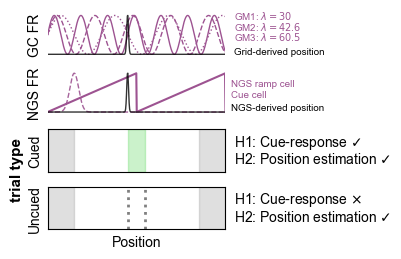

In [6]:

# --- Grid cells, ramp cells, and track cues: 4-row plot with annotations ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

track_length = 200
half_track   = track_length / 2
x = np.linspace(0, track_length, 400)
periods = [30, 30*1.42, 30*1.42**2]
colors  = ['#9d5391', '#9d5391', '#9d5391']

fig, axes = plt.subplots(4, 1, figsize=(4, 2.7), sharex=True,
                         gridspec_kw={'height_ratios': [0.7, 0.7, 0.7, 0.7]})

# ── Row 0: grid cell firing rates ────────────────────────────────────────────
linestyles = ['-', '--', ':']
for p, c, ls in zip(periods, colors, linestyles):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    axes[0].plot(x, y, color=c, lw=1, ls=ls)

G = norm.pdf(x, 90, 1);  G = G / G.max()
G_cue = norm.pdf(x, 30, 5);  G_cue = G_cue / G_cue.max()

axes[0].plot(x, G, color='black', lw=1, alpha=0.8)
axes[0].set_xlim(0, 200);  axes[0].set_yticks([]);  axes[0].set_xticks([])
axes[0].set_ylabel('GC FR')
for sp in ['top', 'right', 'left', 'bottom']:
    axes[0].spines[sp].set_visible(False)
axes[0].text(1.05, 1.10, r'GM1: $\lambda=30$',     color=colors[0], fontsize=7, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.85, r'GM2: $\lambda=42.6$',     color=colors[1], fontsize=7, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.60, r'GM3: $\lambda=60.5$',     color=colors[2], fontsize=7, transform=axes[0].transAxes, va='top')
axes[0].text(1.05, 0.20, r'Grid-derived position', color='black',   fontsize=7, transform=axes[0].transAxes, va='top')

# ── Row 1: NGS ramp cell + cue cell with ramp-derived position readout at 90 cm ──
ramp = (x % half_track) / half_track          # sawtooth: 0→1, 0→1
axes[1].plot(x, ramp, color="#9d5391", lw=1.5)

# Cue cell: Gaussian at 30 cm, SD=5
axes[1].plot(x, G_cue, color='#9d5391', ls='--', lw=1, alpha=0.9)

# Position readout: find ramp value at x = 90
x_probe   = 90.0
y_probe   = (x_probe % half_track) / half_track   # = 0.9

# Dashed cross-hair lines meeting at the intersection point
axes[1].plot(x, G, color='black', lw=1, alpha=0.8)
axes[1].set_xlim(0, 200)
axes[1].set_yticks([]);     axes[1].set_xticks([])
axes[1].set_ylabel('NGS FR')
for sp in ['top', 'right', 'left', 'bottom']:
    axes[1].spines[sp].set_visible(False)
axes[1].text(1.03, 0.70, 'NGS ramp cell',       color="#9d5391", fontsize=7,
             transform=axes[1].transAxes, va='center')
axes[1].text(1.03, 0.45, 'Cue cell',             color="#9d5391",      fontsize=7,
             transform=axes[1].transAxes, va='center')
axes[1].text(1.03, 0.15, 'NGS-derived position', color='black',        fontsize=7,
             transform=axes[1].transAxes, va='center', alpha=1)

# ── Row 2: Cued track ─────────────────────────────────────────────────────────
axes[2].fill_betweenx([0, 1], 90, 110,  color='limegreen', alpha=0.25, zorder=0)
axes[2].fill_betweenx([0, 1],  0,  30,  color='grey',      alpha=0.25, zorder=0)
axes[2].fill_betweenx([0, 1], 170, 200, color='grey',      alpha=0.25, zorder=0)
axes[2].set_xlim(0, 200);  axes[2].set_ylim(0, 1);  axes[2].set_yticks([]);  axes[2].set_xticks([])
axes[2].set_ylabel('Cued')
axes[2].text(1.05, 0.70, r'H1: Cue-response $\checkmark$',       va='center', ha='left', fontsize=10, transform=axes[2].transAxes)
axes[2].text(1.05, 0.30, r'H2: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[2].transAxes)

# ── Row 3: Uncued track ───────────────────────────────────────────────────────
axes[3].axvline(90,  color='grey', ls=':', lw=2)
axes[3].axvline(110, color='grey', ls=':', lw=2)
axes[3].fill_betweenx([0, 1],  0,  30,  color='grey', alpha=0.25, zorder=0)
axes[3].fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
axes[3].set_xlim(0, 200);  axes[3].set_ylim(0, 1);  axes[3].set_yticks([])
axes[3].set_ylabel('Uncued')
axes[3].set_xlabel('Position')
axes[3].text(1.05, 0.70, r'H1: Cue-response $\times$',           va='center', ha='left', fontsize=10, transform=axes[3].transAxes)
axes[3].text(1.05, 0.30, r'H2: Position estimation $\checkmark$', va='center', ha='left', fontsize=10, transform=axes[3].transAxes)

fig.text(0.01, 0.35, 'trial type', va='center', ha='center',
         rotation='vertical', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('task_anchoring_schematic_annotated_v2.pdf', dpi=300, bbox_inches='tight')
plt.show()


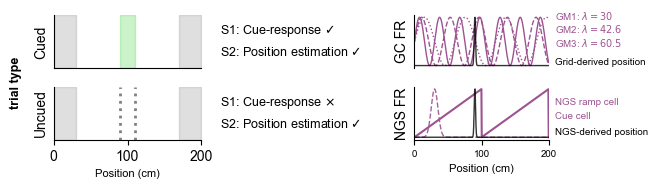

In [43]:
# --- Grid cells, ramp cells, and track cues: 2×2 layout (trial types | FR plots) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

track_length = 200
half_track   = track_length / 2
x = np.linspace(0, track_length, 400)
periods = [30, 30*1.42, 30*1.42**2]
colors  = ['#9d5391', '#9d5391', '#9d5391']

G     = norm.pdf(x, 90, 1);   G     /= G.max()
G_cue = norm.pdf(x, 30, 5);   G_cue /= G_cue.max()
ramp  = (x % half_track) / half_track

fig = plt.figure(figsize=(7.5,1.6))
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1.1, 1.4, 1.0],   # trial-type tracks | H1/H2 text gap | FR plots
    wspace=0.08, hspace=0.35,
    left=0.06, right=0.72, top=0.92, bottom=0.14,
)

ax_cued   = fig.add_subplot(gs[0, 0])
ax_uncued = fig.add_subplot(gs[1, 0])
ax_gap0   = fig.add_subplot(gs[0, 1]); ax_gap0.axis('off')
ax_gap1   = fig.add_subplot(gs[1, 1]); ax_gap1.axis('off')
ax_gc     = fig.add_subplot(gs[0, 2])
ax_ngs    = fig.add_subplot(gs[1, 2])

# ── Cued track (top-left) ─────────────────────────────────────────────────
ax_cued.fill_betweenx([0, 1], 90, 110,  color='limegreen', alpha=0.25, zorder=0)
ax_cued.fill_betweenx([0, 1],  0,  30,  color='grey',      alpha=0.25, zorder=0)
ax_cued.fill_betweenx([0, 1], 170, 200, color='grey',      alpha=0.25, zorder=0)
ax_cued.set_xlim(0, 200); ax_cued.set_ylim(0, 1)
ax_cued.set_yticks([]); ax_cued.set_xticks([])
ax_cued.set_ylabel('Cued')
ax_cued.spines['top'].set_visible(False); ax_cued.spines['right'].set_visible(False)

# ── Uncued track (bottom-left) ────────────────────────────────────────────
ax_uncued.axvline(90,  color='grey', ls=':', lw=2)
ax_uncued.axvline(110, color='grey', ls=':', lw=2)
ax_uncued.fill_betweenx([0, 1],  0,  30,  color='grey', alpha=0.25, zorder=0)
ax_uncued.fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
ax_uncued.set_xlim(0, 200); ax_uncued.set_ylim(0, 1)
ax_uncued.set_yticks([])
ax_uncued.set_ylabel('Uncued')
ax_uncued.set_xlabel('Position (cm)', fontsize=8)
ax_uncued.spines['top'].set_visible(False); ax_uncued.spines['right'].set_visible(False)

# ── 'trial type' rotated label ────────────────────────────────────────────
fig.text(0.01, 0.5, 'trial type', va='center', ha='center',
         rotation='vertical', fontsize=9, fontweight='bold')

# ── H1/H2 annotations in gap column ──────────────────────────────────────
ax_gap0.text(0.03, 0.70, r'S1: Cue-response $\checkmark$',        va='center', ha='left', fontsize=9, transform=ax_gap0.transAxes)
ax_gap0.text(0.03, 0.30, r'S2: Position estimation $\checkmark$',  va='center', ha='left', fontsize=9, transform=ax_gap0.transAxes)
ax_gap1.text(0.03, 0.70, r'S1: Cue-response $\times$',             va='center', ha='left', fontsize=9, transform=ax_gap1.transAxes)
ax_gap1.text(0.03, 0.30, r'S2: Position estimation $\checkmark$',  va='center', ha='left', fontsize=9, transform=ax_gap1.transAxes)

# ── GC FR (top-right) ─────────────────────────────────────────────────────
linestyles = ['-', '--', ':']
for p, c, ls in zip(periods, colors, linestyles):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    ax_gc.plot(x, y, color=c, lw=1, ls=ls)
ax_gc.plot(x, G, color='black', lw=1, alpha=0.8)
ax_gc.set_xlim(0, 200); ax_gc.set_yticks([]); ax_gc.set_xticks([])
ax_gc.set_ylabel('GC FR')
for sp in ['top', 'right', 'left', 'bottom']:
    ax_gc.spines[sp].set_visible(False)
ax_gc.text(1.05, 1.10, r'GM1: $\lambda=30$',     color=colors[0], fontsize=7, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.05, 0.85, r'GM2: $\lambda=42.6$',   color=colors[1], fontsize=7, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.05, 0.60, r'GM3: $\lambda=60.5$',   color=colors[2], fontsize=7, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.05, 0.20, r'Grid-derived position', color='black',   fontsize=7, transform=ax_gc.transAxes, va='top')

# ── NGS FR (bottom-right) ─────────────────────────────────────────────────
ax_ngs.plot(x, ramp,  color="#9d5391", lw=1.5)
ax_ngs.plot(x, G_cue, color='#9d5391', ls='--', lw=1, alpha=0.9)
ax_ngs.plot(x, G,     color='black',   lw=1, alpha=0.8)
ax_ngs.set_xlim(0, 200)
ax_ngs.set_yticks([])
ax_ngs.set_xticks([0, 100, 200]); ax_ngs.set_xticklabels(['0', '100', '200'], fontsize=7)
ax_ngs.set_xlabel('Position (cm)', fontsize=8)
ax_ngs.set_ylabel('NGS FR')
for sp in ['top', 'right', 'left', 'bottom']:
    ax_ngs.spines[sp].set_visible(False)
ax_ngs.spines['bottom'].set_visible(True)
ax_ngs.spines['left'].set_visible(True)
ax_gc.spines['left'].set_visible(True)

ax_ngs.text(1.05, 0.70, 'NGS ramp cell',       color="#9d5391", fontsize=7, transform=ax_ngs.transAxes, va='center')
ax_ngs.text(1.05, 0.45, 'Cue cell',             color="#9d5391", fontsize=7, transform=ax_ngs.transAxes, va='center')
ax_ngs.text(1.05, 0.15, 'NGS-derived position', color='black',   fontsize=7, transform=ax_ngs.transAxes, va='center')

plt.savefig('task_anchoring_schematic_annotated_v2.pdf', dpi=300, bbox_inches='tight')
plt.show()

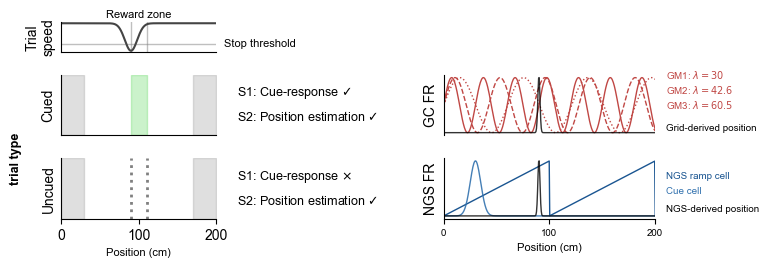

In [49]:
# --- Grid cells, ramp cells, and track cues: 3×3 layout (speed + trial types | H1/H2 gap | FR plots) ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

track_length = 200
half_track   = track_length / 2
x = np.linspace(0, track_length, 400)
periods = [30, 30*1.42, 30*1.42**2]
colors  = [gc_color,gc_color,gc_color]

G     = norm.pdf(x, 90, 1);   G     /= G.max()
G_cue = norm.pdf(x, 30, 5);   G_cue /= G_cue.max()
ramp  = (x % half_track) / half_track

# Speed profile: high at 0, smooth dip centred on reward zone (~90 cm), high again to 200
speed = 1 - 0.65 * np.exp(-((x - 90)**2) / (2 * 8**2))

fig = plt.figure(figsize=(9, 2.4))
gs = gridspec.GridSpec(
    3, 3,
    width_ratios=[1.1, 1.4, 1.5],
    height_ratios=[0.5, 1.0, 1.0],
    wspace=0.08, hspace=0.45,
    left=0.06, right=0.72, top=0.92, bottom=0.10,
)

ax_speed  = fig.add_subplot(gs[0, 0])
ax_sgap0  = fig.add_subplot(gs[0, 1]); ax_sgap0.axis('off')
ax_sgap1  = fig.add_subplot(gs[0, 2]); ax_sgap1.axis('off')
ax_cued   = fig.add_subplot(gs[1, 0])
ax_uncued = fig.add_subplot(gs[2, 0])
ax_gap0   = fig.add_subplot(gs[1, 1]); ax_gap0.axis('off')
ax_gap1   = fig.add_subplot(gs[2, 1]); ax_gap1.axis('off')
ax_gc     = fig.add_subplot(gs[1, 2])
ax_ngs    = fig.add_subplot(gs[2, 2])

# ── Speed profile (top-left) ──────────────────────────────────────────────
ax_speed.axvline(90, color='grey', lw=1, alpha=0.5)
ax_speed.axvline(110, color='grey', lw=1, alpha=0.5)
ax_speed.axhline(0.5, color='grey', lw=1, alpha=0.5)
ax_speed.plot(x, speed, color='#444444', lw=1.5)
ax_speed.set_xlim(0, 200)
ax_speed.set_yticks([])
ax_speed.set_xticks([])
ax_speed.set_ylabel('Trial\nspeed', fontsize=10)
ax_speed.text(1.05, 0.45, r'Stop threshold ',     color='black', fontsize=8, transform=ax_speed.transAxes, va='top')
ax_speed.text(0.5, 1.4, r'Reward zone', color='black', fontsize=8, transform=ax_speed.transAxes, va='top', ha='center')
ax_speed.spines['top'].set_visible(False)
ax_speed.spines['right'].set_visible(False)

# ── Cued track (middle-left) ──────────────────────────────────────────────
ax_cued.fill_betweenx([0, 1], 90, 110,  color='limegreen', alpha=0.25, zorder=0)
ax_cued.fill_betweenx([0, 1],  0,  30,  color='grey',      alpha=0.25, zorder=0)
ax_cued.fill_betweenx([0, 1], 170, 200, color='grey',      alpha=0.25, zorder=0)
ax_cued.set_xlim(0, 200); ax_cued.set_ylim(0, 1)
ax_cued.set_yticks([]); ax_cued.set_xticks([])
ax_cued.set_ylabel('Cued')
ax_cued.spines['top'].set_visible(False); ax_cued.spines['right'].set_visible(False)

# ── Uncued track (bottom-left) ────────────────────────────────────────────
ax_uncued.axvline(90,  color='grey', ls=':', lw=2)
ax_uncued.axvline(110, color='grey', ls=':', lw=2)
ax_uncued.fill_betweenx([0, 1],  0,  30,  color='grey', alpha=0.25, zorder=0)
ax_uncued.fill_betweenx([0, 1], 170, 200, color='grey', alpha=0.25, zorder=0)
ax_uncued.set_xlim(0, 200); ax_uncued.set_ylim(0, 1)
ax_uncued.set_yticks([])
ax_uncued.set_ylabel('Uncued')
ax_uncued.set_xlabel('Position (cm)', fontsize=8)
ax_uncued.spines['top'].set_visible(False); ax_uncued.spines['right'].set_visible(False)

# ── 'trial type' rotated label (centred on cued/uncued rows) ─────────────
fig.text(0.01, 0.35, 'trial type', va='center', ha='center',
         rotation='vertical', fontsize=9, fontweight='bold')

# ── H1/H2 annotations in gap column ──────────────────────────────────────
ax_gap0.text(0.03, 0.70, r'S1: Cue-response $\checkmark$',        va='center', ha='left', fontsize=9, transform=ax_gap0.transAxes)
ax_gap0.text(0.03, 0.30, r'S2: Position estimation $\checkmark$',  va='center', ha='left', fontsize=9, transform=ax_gap0.transAxes)
ax_gap1.text(0.03, 0.70, r'S1: Cue-response $\times$',             va='center', ha='left', fontsize=9, transform=ax_gap1.transAxes)
ax_gap1.text(0.03, 0.30, r'S2: Position estimation $\checkmark$',  va='center', ha='left', fontsize=9, transform=ax_gap1.transAxes)

# ── GC FR (middle-right) ──────────────────────────────────────────────────
linestyles = ['-', '--', ':']
for p, c, ls in zip(periods, colors, linestyles):
    y = np.sin(2 * np.pi * x / p)
    y = (y - y.min()) / (y.max() - y.min())
    ax_gc.plot(x, y, color=c, lw=1, ls=ls)
ax_gc.plot(x, G, color='black', lw=1, alpha=0.8)
ax_gc.set_xlim(0, 200); ax_gc.set_yticks([]); ax_gc.set_xticks([])
ax_gc.set_ylabel('GC FR')
for sp in ['top', 'right', 'bottom']:
    ax_gc.spines[sp].set_visible(False)
ax_gc.spines['left'].set_visible(True)
ax_gc.text(1.05, 1.10, r'GM1: $\lambda=30$',     color=colors[0], fontsize=7, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.05, 0.85, r'GM2: $\lambda=42.6$',   color=colors[1], fontsize=7, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.05, 0.60, r'GM3: $\lambda=60.5$',   color=colors[2], fontsize=7, transform=ax_gc.transAxes, va='top')
ax_gc.text(1.05, 0.20, r'Grid-derived position', color='black',   fontsize=7, transform=ax_gc.transAxes, va='top')

# ── NGS FR (bottom-right) ─────────────────────────────────────────────────
ax_ngs.plot(x, ramp,  color="#1a5591", lw=1)
ax_ngs.plot(x, G_cue, color='#3171ae', lw=1, alpha=0.9)
ax_ngs.plot(x, G,     color='black',   lw=1, alpha=0.8)
ax_ngs.set_xlim(0, 200)
ax_ngs.set_yticks([])
ax_ngs.set_xticks([0, 100, 200]); ax_ngs.set_xticklabels(['0', '100', '200'], fontsize=7)
ax_ngs.set_xlabel('Position (cm)', fontsize=8)
ax_ngs.set_ylabel('NGS FR')
for sp in ['top', 'right']:
    ax_ngs.spines[sp].set_visible(False)
ax_ngs.spines['bottom'].set_visible(True)
ax_ngs.spines['left'].set_visible(True)

ax_ngs.text(1.05, 0.70, 'NGS ramp cell',       color="#1a5591", fontsize=7, transform=ax_ngs.transAxes, va='center')
ax_ngs.text(1.05, 0.45, 'Cue cell',             color="#3171ae", fontsize=7, transform=ax_ngs.transAxes, va='center')
ax_ngs.text(1.05, 0.15, 'NGS-derived position', color='black',   fontsize=7, transform=ax_ngs.transAxes, va='center')

plt.savefig('task_anchoring_schematic_annotated_v2.pdf', dpi=300, bbox_inches='tight')
plt.show()

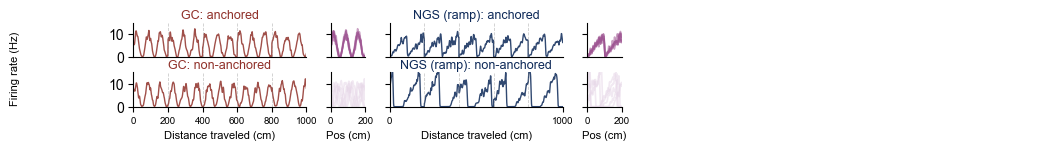

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

rng = np.random.default_rng(4)

# ── Parameters ────────────────────────────────────────────────────────────
track_length    = 200
n_trials        = 5
n_bins          = 400
period          = 70
half_track      = track_length / 2
ramp_width      = 100
bin_width       = track_length / n_bins   # 0.5 cm / bin
sigma_bins      = 2.0 / bin_width         # Gaussian SD = 2 cm → 4 bins
mean_spikes     = 1000
trial_positions = np.linspace(0, track_length, n_bins)
x_unrav         = np.linspace(0, n_trials * track_length, n_trials * n_bins)

# Column 0 & 2 (unravelled): distinct colour per cell type, same across rows
col_gc_unrav   = '#90312a'
col_ngs_unrav  = ngs_color_dark
# Columns 1 & 3 (overlaid): anchored / non-anchored
col_ov_anch    = '#9d5391'
col_ov_nonanch = '#e7d7e8'

# ── Helpers ───────────────────────────────────────────────────────────────
def _make_profile(y):
    mn, mx = y.min(), y.max()
    return (y - mn) / (mx - mn) if mx > mn else y

def _sample_and_reconstruct(rate_profile, rng_obj):
    pdf  = rate_profile / rate_profile.sum()
    n_sp = rng_obj.poisson(mean_spikes)
    if n_sp == 0:
        return np.zeros(len(rate_profile))
    spike_idx = rng_obj.choice(len(pdf), size=n_sp, p=pdf)
    counts, _ = np.histogram(spike_idx, bins=np.arange(len(pdf) + 1) - 0.5)
    fr = counts.astype(float) / bin_width
    return gaussian_filter1d(fr, sigma=sigma_bins)

def _reconstruct_all(profiles, rng_obj):
    return [_sample_and_reconstruct(p, rng_obj) for p in profiles]

def _plot_unravelled(ax, frs, color, title, ylabel=None, show_xaxis=False):
    """Concatenate all trials into one continuous trace (0 → n_trials*200 cm)."""
    fr_cat = np.concatenate(frs)
    ax.plot(x_unrav, fr_cat, color=color, alpha=0.85, lw=1.0)
    for t in range(1, n_trials):
        ax.axvline(t * track_length, color='grey', lw=0.6, ls='--', alpha=0.4)
    ax.set_title(title, color=color, fontsize=9, pad=3)
    ax.set_xlim(0, n_trials * track_length)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8)
    if show_xaxis:
        ax.set_xticks([0, n_trials * track_length])
        ax.set_xticklabels(['0', f'{n_trials * track_length}'], fontsize=7)
        ax.set_xlabel('Distance traveled (cm)', fontsize=8)
    else:
        ax.set_xticks([])

def _plot_overlaid(ax, frs, color, title, ylabel=None, show_xaxis=False):
    """Overlay each trial's FR on 0–200 cm axes."""
    for fr in frs:
        ax.plot(trial_positions, fr, color=color, alpha=0.55, lw=1.2)
    ax.set_title(title, color=color, fontsize=9, pad=3)
    ax.set_xlim(0, track_length)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8)
    if show_xaxis:
        ax.set_xticks([0, track_length])
        ax.set_xticklabels(['0', f'{track_length}'], fontsize=7)
        ax.set_xlabel('Pos (cm)', fontsize=8)
    else:
        ax.set_xticks([])

# ── Rate profiles ─────────────────────────────────────────────────────────
gc_anch_profiles = [
    _make_profile(np.sin(2 * np.pi * trial_positions / period))
    for _ in range(n_trials)
]
gc_nonanch_profiles = [
    _make_profile(np.sin(2 * np.pi * (trial_positions + t * track_length) / period))
    for t in range(n_trials)
]

sawtooth = (trial_positions % half_track) / half_track
ngs_anch_profiles = [sawtooth.copy() for _ in range(n_trials)]

ngs_nonanch_profiles = []
for _ in range(n_trials):
    silence = rng.uniform(10, 60)
    cycle   = ramp_width + silence
    phase   = rng.uniform(0, cycle)
    xs      = (trial_positions + phase) % cycle
    rv      = xs / ramp_width
    rv[xs >= ramp_width] = 0
    ngs_nonanch_profiles.append(rv.copy())

# Reconstruct once; shared by both unravelled and overlaid views
gc_anch_frs     = _reconstruct_all(gc_anch_profiles,     rng)
gc_nonanch_frs  = _reconstruct_all(gc_nonanch_profiles,  rng)
ngs_anch_frs    = _reconstruct_all(ngs_anch_profiles,    rng)
ngs_nonanch_frs = _reconstruct_all(ngs_nonanch_profiles, rng)

# ── Figure: 2 rows × 5 cols ───────────────────────────────────────────────
fig, axes = plt.subplots(
    nrows=2, ncols=5,
    figsize=(rm_figsize[0] * 11.75, rm_figsize[1] * 0.75),
    width_ratios=[5, 1, 5, 1, 11.5],
    sharey='row',
)

# Row 0: anchored
_plot_unravelled(axes[0, 0], gc_anch_frs,    col_gc_unrav,  'GC: anchored',
                 show_xaxis=False)
_plot_overlaid(  axes[0, 1], gc_anch_frs,    col_ov_anch,   '',
                 show_xaxis=False)
_plot_unravelled(axes[0, 2], ngs_anch_frs,   col_ngs_unrav, 'NGS (ramp): anchored',
                 show_xaxis=False)
_plot_overlaid(  axes[0, 3], ngs_anch_frs,   col_ov_anch,   '',
                 show_xaxis=False)

# Row 1: non-anchored
_plot_unravelled(axes[1, 0], gc_nonanch_frs,  col_gc_unrav,   'GC: non-anchored',
                 show_xaxis=True)
_plot_overlaid(  axes[1, 1], gc_nonanch_frs,  col_ov_nonanch, '',
                 show_xaxis=True)
_plot_unravelled(axes[1, 2], ngs_nonanch_frs, col_ngs_unrav,  'NGS (ramp): non-anchored',
                 show_xaxis=True)
_plot_overlaid(  axes[1, 3], ngs_nonanch_frs, col_ov_nonanch, '',
                 show_xaxis=True)

axes[0, 4].axis('off')
axes[1, 4].axis('off')
axes[1,0].set_xticks([0, 200, 400, 600, 800, 1000])
axes[1,0].set_xticklabels(['0', '200', '400', '600', '800', '1000'], fontsize=7)
fig.supylabel('Firing rate (Hz)', fontsize=8, )
axes[0, 0].set_ylim(0, 15)
axes[1, 0].set_ylim(0, 15)

plt.subplots_adjust(wspace=0.15, hspace=0.45, bottom=0.18)
plt.savefig('schematic_grid_and_ramp_anchoring.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Schematic illustration of the Position Estimation Index (PEI) and anchoring improvement types
This figure demonstrates how the Position Estimation Index (PEI) is computed and interpreted for simulated cells with different anchoring improvement profiles. It visualizes the effect of anchoring on hit probability across trial types, using synthetic data to illustrate the logic of the PEI metric.

**Figure layout:**
- **Top panels:** Show simulated trial-by-trial data for each cell type, with both the original and shuffled anchoring labels. Each row corresponds to either real or shuffled anchoring. Columns show trial type, rate map, anchoring state, and hit rasters for each cell type. Both unsorted and condition-sorted versions are shown.
- **Cell types:** Six example cell types are simulated:
    1. Null (random hits)
    2. Cued and uncued (anchoring improves both)
    3. Uncued only (anchoring improves only uncued)
    4. Cued only (anchoring improves only cued)
    5. Cued > Uncued (anchoring effect is stronger for cued)
    6. Cued < Uncued (anchoring effect is stronger for uncued)
- **Bottom panels:** Violin plots show the distribution of PEI values across many simulations for each cell type, comparing real and shuffled anchoring labels.

**Interpretation:**
- The PEI quantifies how much anchoring improves position estimation, specifically comparing the effect in uncued vs. cued trials:
  $$\text{PEI} = (\Delta \text{hit rate}_{\text{uncued}}) - (\Delta \text{hit rate}_{\text{cued}})$$
- Positive PEI: Anchoring improves uncued trials more than cued trials.
- Negative PEI: Anchoring improves cued trials more than uncued trials.
- Shuffling anchoring labels destroys the relationship, centering the PEI distribution around zero.

This schematic helps clarify how the PEI metric distinguishes between different patterns of anchoring-related improvement in simulated cells.

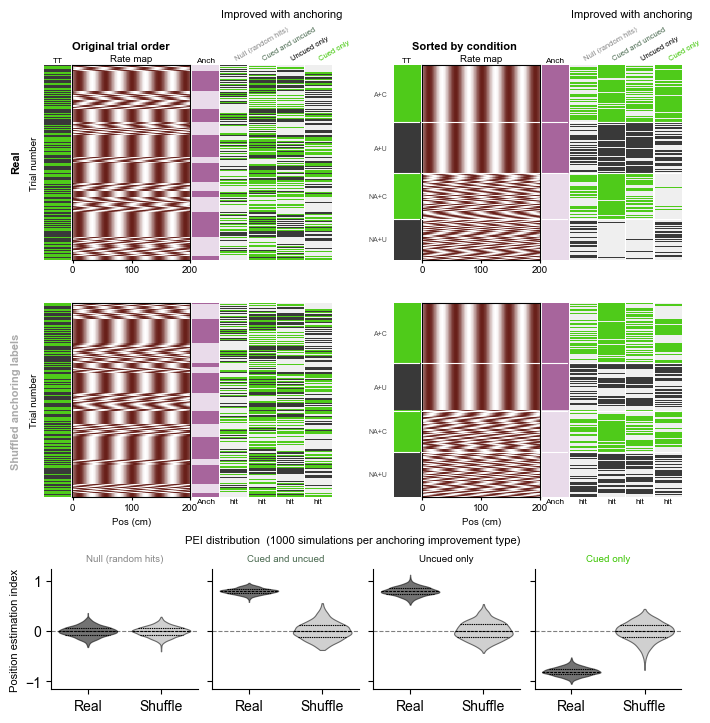

In [130]:
# ── PEI schematic: one shared rate map, 4 hit types, unsorted+sorted, actual+shuffle ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
import seaborn as sns
import pandas as pd

rng = np.random.default_rng(42)

N_TRIALS   = 400
N_BINS     = 200
TRACK_LEN  = 200
PERIOD     = 45
N_REPS     = 1000
SHUF_SHIFT = N_TRIALS // 3

def make_streaks(n, rng, lo=10, hi=50):
    labels, i, state = np.zeros(n, dtype=int), 0, 0
    while i < n:
        l = int(rng.integers(lo, hi + 1))
        labels[i:i + l] = state; i += l; state ^= 1
    return labels

anchoring      = make_streaks(N_TRIALS, rng)
trial_types    = rng.integers(0, 2, size=N_TRIALS)
anchoring_shuf = np.roll(anchoring, SHUF_SHIFT)
pos            = np.linspace(0, TRACK_LEN, N_BINS)

def build_rate_map(anch_arr, seed=99):
    rng_rm = np.random.default_rng(seed)
    rm = np.zeros((N_TRIALS, N_BINS))
    for t in range(N_TRIALS):
        phase = 0.0 if anch_arr[t] else float(rng_rm.uniform(0, PERIOD))
        rm[t] = np.sin(2 * np.pi * (pos + phase) / PERIOD)
    rm = (rm - rm.min()) / (rm.max() - rm.min())
    return rm

rate_map      = build_rate_map(anchoring,      seed=99)
rate_map_shuf = build_rate_map(anchoring_shuf, seed=99)

def make_sort(anch_arr, tt_arr):
    key = (1 - anch_arr) * 2 + tt_arr
    idx = np.argsort(key, kind='stable')
    gsz = np.array([np.sum(key == g) for g in range(4)])
    gbd = np.cumsum(gsz[:-1])
    ab  = int(gsz[0] + gsz[1])
    return idx, gsz, gbd, ab

sort_idx_a, grp_sizes_a, grp_bounds_a, anch_bound_a = make_sort(anchoring,      trial_types)
sort_idx_s, grp_sizes_s, grp_bounds_s, anch_bound_s = make_sort(anchoring_shuf, trial_types)
GRP_LABELS = ['A+C', 'A+U', 'NA+C', 'NA+U']

def simulate_hits(anchoring, trial_types, p_cued_na, p_uncued_na, p_cued_a, p_uncued_a, rng):
    probs = np.where(trial_types == 0,
                     np.where(anchoring == 1, p_cued_a,   p_cued_na),
                     np.where(anchoring == 1, p_uncued_a, p_uncued_na))
    return (rng.random(len(anchoring)) < probs).astype(int)

def compute_pei(anchoring, trial_types, hits):
    d = {}
    for tt, key in [(0, 'c'), (1, 'u')]:
        am = (anchoring == 1) & (trial_types == tt)
        nm = (anchoring == 0) & (trial_types == tt)
        d[key] = hits[am].mean() - hits[nm].mean() if (am.any() and nm.any()) else np.nan
    return d['u'] - d['c'], d['c'], d['u']

def encode_hits(hits, trial_types):
    enc = np.zeros(len(hits))
    enc[(hits == 1) & (trial_types == 0)] = 1
    enc[(hits == 1) & (trial_types == 1)] = 2
    return enc

def strip(ax, data, cmap, norm=None):
    kw = dict(aspect='auto', interpolation='nearest', origin='upper')
    if norm is not None: kw['norm'] = norm
    ax.imshow(data[:, np.newaxis], cmap=cmap, alpha=0.9, **kw)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

def mark_groups(ax, grp_bounds, anch_bound):
    for b in grp_bounds:
        lw = 0.8
        ax.axhline(b - 0.5, color='white', lw=lw, zorder=5)

def rotated_title(ax, text, color='black', fontsize=5.5):
    ax.text(0.5, 1.02, text.replace('\n', ' '),
            transform=ax.transAxes, ha='left', va='bottom',
            fontsize=fontsize, color=color, rotation=30, clip_on=False)

cell_defs = [
    ('Null\n(random hits)',                '#888888',      0.50, 0.50, 0.50, 0.50),
    ('Cued and uncued',                    "#49694F",      0.90, 0.10, 0.90, 0.90),
    ('Uncued only',                        "#000000",      0.50, 0.10, 0.50, 0.90),
    ('Cued only',                           '#3bc500',        0.10, 0.50, 0.90, 0.50),
]
cells = []
for label, color, *params in cell_defs:
    hits = simulate_hits(anchoring, trial_types, *params, rng)
    pei,      dhr_c, dhr_u = compute_pei(anchoring,      trial_types, hits)
    pei_shuf, _,     _     = compute_pei(anchoring_shuf, trial_types, hits)
    cells.append(dict(label=label, color=color, params=params, hits=hits,
                      pei=pei, dhr_c=dhr_c, dhr_u=dhr_u, pei_shuf=pei_shuf))

cells_show = cells   # Null, GA, PE, CR

gc_cmap  = LinearSegmentedColormap.from_list('gc', ['white', '#69201a'])
ta_cmap  = ListedColormap(["#e7d7e8", "#9d5391"]); ta_norm = BoundaryNorm([-0.5, 0.5, 1.5], ta_cmap.N)
tt_cmap  = ListedColormap(["#3bc500",  "#222222"]); tt_norm = BoundaryNorm([-0.5, 0.5, 1.5], tt_cmap.N)
hit_cmap = ListedColormap(["#eeeeee",  "#3bc500", "#222222"])
hit_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], hit_cmap.N)

# col:  [tt | rm | ta | Null | GA | PE | CR]  gap  [tt | rm | ta | Null | GA | PE | CR]
#         0    1    2    3     4    5    6    7       8    9   10    11   12   13   14
col_w = [0.18, 0.8, 0.18, 0.18, 0.18, 0.18, 0.18,
         0.4,
         0.18, 0.8, 0.18, 0.18, 0.18, 0.18, 0.18]

fig = plt.figure(figsize=(7, 8))
gs_top = gridspec.GridSpec(2, len(col_w), width_ratios=col_w, wspace=0.04, hspace=0.22,
                            left=0.06, right=0.97, top=0.82, bottom=0.28)
gs_bot = gridspec.GridSpec(1, 4, wspace=0.10,
                            left=0.07, right=0.97, top=0.19, bottom=0.04)
fig.text(0.4, 0.88, 'Improved with anchoring',             ha='center', fontsize=8)
fig.text(0.9, 0.88, 'Improved with anchoring',             ha='center', fontsize=8)


fig.text(0.17, 0.84, 'Original trial order',             ha='center', fontsize=8, fontweight='bold')
fig.text(0.66, 0.84, 'Sorted by condition',              ha='center', fontsize=8, fontweight='bold')
fig.text(0.02, 0.7, 'Real',                              ha='center', fontsize=8, rotation=90, va='center', fontweight='bold', color="#000000")
fig.text(0.02, 0.4, 'Shuffled anchoring labels',         ha='center', fontsize=8, rotation=90, va='center', fontweight='bold', color='#aaaaaa')

def draw_row(r, anchoring_arr, sort_idx, grp_sizes, grp_bounds, anch_bound,
             rm, ylabel, ylabel_color='black', is_bottom=False):

    # ── Unsorted section ──────────────────────────────────────────────────
    ax_tt = fig.add_subplot(gs_top[r, 0])
    strip(ax_tt, trial_types.astype(float), tt_cmap, tt_norm)
    ax_tt.set_yticks([0, N_TRIALS - 1])
    ax_tt.set_yticklabels([1, N_TRIALS], fontsize=7)
    ax_tt.set_ylabel(ylabel, fontsize=7, color=ylabel_color)
    if r == 0: ax_tt.set_title('TT', fontsize=6, pad=2)

    ax_rm = fig.add_subplot(gs_top[r, 1], sharey=ax_tt)
    ax_rm.imshow(rm, aspect='auto', cmap=gc_cmap, vmin=0, vmax=1,
                 interpolation='nearest', origin='upper')
    ax_rm.set_yticks([])
    ax_rm.set_xticks([0, N_BINS // 2, N_BINS - 1])
    ax_rm.set_xticklabels([0, TRACK_LEN // 2, TRACK_LEN], fontsize=7)
    ax_rm.tick_params(axis='x', length=2, pad=2)
    if r == 0: ax_rm.set_title('Rate map', fontsize=7, pad=3)
    if is_bottom: ax_rm.set_xlabel('Pos (cm)', fontsize=7)

    ax_ta = fig.add_subplot(gs_top[r, 2], sharey=ax_tt)
    strip(ax_ta, anchoring_arr.astype(float), ta_cmap, ta_norm)
    if r == 0: ax_ta.set_title('Anch', fontsize=6, pad=2)
    if is_bottom: ax_ta.set_xlabel('Anch', fontsize=6, labelpad=1)

    for j, cd in enumerate(cells_show):
        ax_hi = fig.add_subplot(gs_top[r, 3 + j], sharey=ax_tt)
        strip(ax_hi, encode_hits(cd['hits'], trial_types), hit_cmap, hit_norm)
        if r == 0:
            rotated_title(ax_hi, cd['label'], color=cd['color'])
        if is_bottom:
            ax_hi.set_xlabel('hit', fontsize=6, labelpad=1)

    # ── Sorted section ────────────────────────────────────────────────────
    ax_tt_s = fig.add_subplot(gs_top[r, 8], sharey=ax_tt)
    strip(ax_tt_s, trial_types[sort_idx].astype(float), tt_cmap, tt_norm)
    ax_tt_s.set_yticks([])
    mark_groups(ax_tt_s, grp_bounds, anch_bound)
    if r == 0: ax_tt_s.set_title('TT', fontsize=6, pad=2)
    cum = 0
    for glab, gsz in zip(GRP_LABELS, grp_sizes):
        mid_frac = 1.0 - (cum + gsz / 2) / N_TRIALS
        ax_tt_s.text(-0.25, mid_frac, glab, transform=ax_tt_s.transAxes,
                     ha='right', va='center', fontsize=5, color='#555555')
        cum += gsz

    ax_rm_s = fig.add_subplot(gs_top[r, 9], sharey=ax_tt)
    ax_rm_s.imshow(rm[sort_idx], aspect='auto', cmap=gc_cmap, vmin=0, vmax=1,
                   interpolation='nearest', origin='upper')
    ax_rm_s.set_yticks([])
    ax_rm_s.set_xticks([0, N_BINS // 2, N_BINS - 1])
    ax_rm_s.set_xticklabels([0, TRACK_LEN // 2, TRACK_LEN], fontsize=7)
    ax_rm_s.tick_params(axis='x', length=2, pad=2)
    mark_groups(ax_rm_s, grp_bounds, anch_bound)
    if r == 0: ax_rm_s.set_title('Rate map', fontsize=7, pad=3)
    if is_bottom: ax_rm_s.set_xlabel('Pos (cm)', fontsize=7)

    ax_ta_s = fig.add_subplot(gs_top[r, 10], sharey=ax_tt)
    strip(ax_ta_s, anchoring_arr[sort_idx].astype(float), ta_cmap, ta_norm)
    mark_groups(ax_ta_s, grp_bounds, anch_bound)
    if r == 0: ax_ta_s.set_title('Anch', fontsize=6, pad=2)
    if is_bottom: ax_ta_s.set_xlabel('Anch', fontsize=6, labelpad=1)

    for j, cd in enumerate(cells_show):
        ax_hi_s = fig.add_subplot(gs_top[r, 11 + j], sharey=ax_tt)
        strip(ax_hi_s, encode_hits(cd['hits'], trial_types)[sort_idx], hit_cmap, hit_norm)
        mark_groups(ax_hi_s, grp_bounds, anch_bound)
        if r == 0:
            rotated_title(ax_hi_s, cd['label'], color=cd['color'])
        if is_bottom:
            ax_hi_s.set_xlabel('hit', fontsize=6, labelpad=1)
        if j == len(cells_show) - 1:
            hits_s = cd['hits'][sort_idx]
            cum2 = 0
            for gsz in grp_sizes:
                hr = hits_s[cum2:cum2 + gsz].mean()
                mid_frac = 1.0 - (cum2 + gsz / 2) / N_TRIALS
                #ax_hi_s.text(1.07, mid_frac, f'{hr:.2f}', transform=ax_hi_s.transAxes,
                #             ha='left', va='center', fontsize=4.5, color='#333333')
                cum2 += gsz

draw_row(0, anchoring,      sort_idx_a, grp_sizes_a, grp_bounds_a, anch_bound_a,
         rm=rate_map,      ylabel='Trial number', is_bottom=False)
draw_row(1, anchoring_shuf, sort_idx_s, grp_sizes_s, grp_bounds_s, anch_bound_s,
         rm=rate_map_shuf, ylabel='Trial number', is_bottom=True)

# ── Bottom: violin distributions ──────────────────────────────────────────────
fig.text(0.5, 0.22, f'PEI distribution  ({N_REPS} simulations per anchoring improvement type)',
         ha='center', va='bottom', fontsize=8)

ax_dist_ref = None
for i, cd in enumerate(cells):
    rng_d = np.random.default_rng(500 + i)
    pei_real, pei_shuf_dist = [], []
    for _ in range(N_REPS):
        a_r  = make_streaks(N_TRIALS, rng_d)
        tt_r = rng_d.integers(0, 2, size=N_TRIALS)
        h_r  = simulate_hits(a_r, tt_r, *cd['params'], rng_d)
        p, _, _  = compute_pei(a_r, tt_r, h_r)
        ps, _, _ = compute_pei(np.roll(a_r, len(a_r) // 3), tt_r, h_r)
        if not np.isnan(p):  pei_real.append(p)
        if not np.isnan(ps): pei_shuf_dist.append(ps)

    ax_d = fig.add_subplot(gs_bot[0, i], sharey=ax_dist_ref)
    if ax_dist_ref is None: ax_dist_ref = ax_d

    df = pd.DataFrame({
        'PEI':  pei_real + pei_shuf_dist,
        'type': ['Real'] * len(pei_real) + ['Shuffle'] * len(pei_shuf_dist),
    })
    sns.violinplot(data=df, x='type', y='PEI', ax=ax_d,
                   order=['Real', 'Shuffle'],
                   palette={'Real': 'black', 'Shuffle': '#aaaaaa'},
                   inner='quart', cut=0, linewidth=0.8, saturation=0.7)
    for art in ax_d.collections:
        art.set_alpha(0.55)

    ax_d.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax_d.set_xlabel('')
    ax_d.tick_params(axis='x', labelsize=10)
    ax_d.set_title(cd['label'].replace('\n', ' '), fontsize=7, color=cd['color'])
    ax_d.spines['top'].set_visible(False)
    ax_d.spines['right'].set_visible(False)
    if i == 0:
        ax_d.set_ylabel('Position estimation index', fontsize=8)
    else:
        ax_d.set_ylabel('')
        ax_d.tick_params(labelleft=False)

plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/pei_schematic_cells.pdf',
    dpi=300, bbox_inches='tight')
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/pei_schematic_cells.png',
    dpi=1000, bbox_inches='tight')
plt.show()

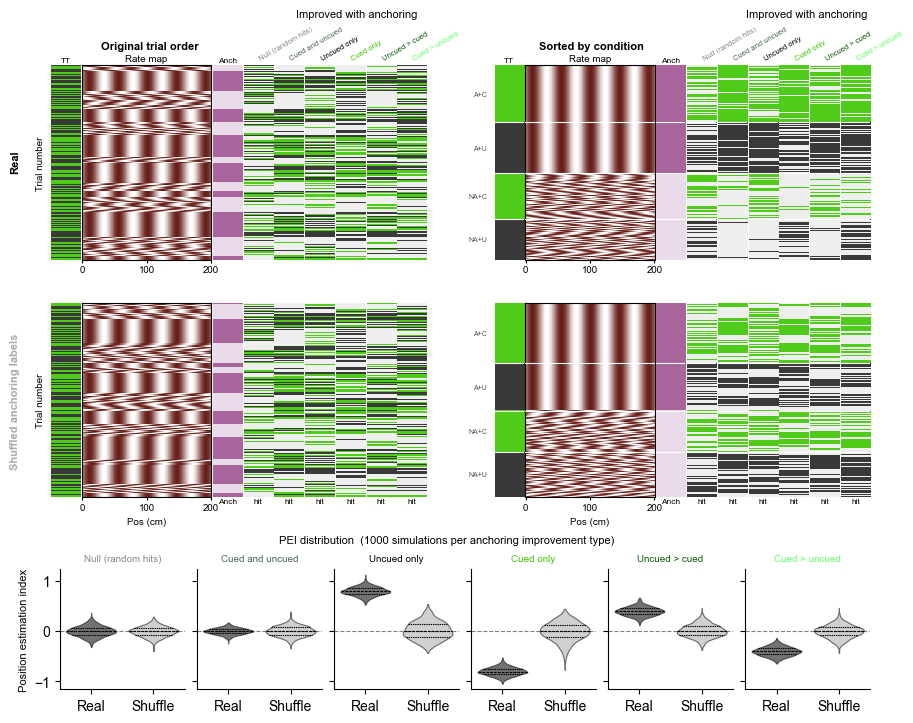

In [129]:
# ── PEI schematic: one shared rate map, 6 hit types, unsorted+sorted, actual+shuffle ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap
import seaborn as sns
import pandas as pd

rng = np.random.default_rng(42)

N_TRIALS   = 400
N_BINS     = 200
TRACK_LEN  = 200
PERIOD     = 45
N_REPS     = 1000
SHUF_SHIFT = N_TRIALS // 3

def make_streaks(n, rng, lo=10, hi=50):
    labels, i, state = np.zeros(n, dtype=int), 0, 0
    while i < n:
        l = int(rng.integers(lo, hi + 1))
        labels[i:i + l] = state; i += l; state ^= 1
    return labels

anchoring      = make_streaks(N_TRIALS, rng)
trial_types    = rng.integers(0, 2, size=N_TRIALS)
anchoring_shuf = np.roll(anchoring, SHUF_SHIFT)
pos            = np.linspace(0, TRACK_LEN, N_BINS)

def build_rate_map(anch_arr, seed=99):
    rng_rm = np.random.default_rng(seed)
    rm = np.zeros((N_TRIALS, N_BINS))
    for t in range(N_TRIALS):
        phase = 0.0 if anch_arr[t] else float(rng_rm.uniform(0, PERIOD))
        rm[t] = np.sin(2 * np.pi * (pos + phase) / PERIOD)
    rm = (rm - rm.min()) / (rm.max() - rm.min())
    return rm

rate_map      = build_rate_map(anchoring,      seed=99)
rate_map_shuf = build_rate_map(anchoring_shuf, seed=99)

def make_sort(anch_arr, tt_arr):
    key = (1 - anch_arr) * 2 + tt_arr
    idx = np.argsort(key, kind='stable')
    gsz = np.array([np.sum(key == g) for g in range(4)])
    gbd = np.cumsum(gsz[:-1])
    ab  = int(gsz[0] + gsz[1])
    return idx, gsz, gbd, ab

sort_idx_a, grp_sizes_a, grp_bounds_a, anch_bound_a = make_sort(anchoring,      trial_types)
sort_idx_s, grp_sizes_s, grp_bounds_s, anch_bound_s = make_sort(anchoring_shuf, trial_types)
GRP_LABELS = ['A+C', 'A+U', 'NA+C', 'NA+U']

def simulate_hits(anchoring, trial_types, p_cued_na, p_uncued_na, p_cued_a, p_uncued_a, rng):
    probs = np.where(trial_types == 0,
                     np.where(anchoring == 1, p_cued_a,   p_cued_na),
                     np.where(anchoring == 1, p_uncued_a, p_uncued_na))
    return (rng.random(len(anchoring)) < probs).astype(int)

def compute_pei(anchoring, trial_types, hits):
    d = {}
    for tt, key in [(0, 'c'), (1, 'u')]:
        am = (anchoring == 1) & (trial_types == tt)
        nm = (anchoring == 0) & (trial_types == tt)
        d[key] = hits[am].mean() - hits[nm].mean() if (am.any() and nm.any()) else np.nan
    return d['u'] - d['c'], d['c'], d['u']

def encode_hits(hits, trial_types):
    enc = np.zeros(len(hits))
    enc[(hits == 1) & (trial_types == 0)] = 1
    enc[(hits == 1) & (trial_types == 1)] = 2
    return enc

def strip(ax, data, cmap, norm=None):
    kw = dict(aspect='auto', interpolation='nearest', origin='upper')
    if norm is not None: kw['norm'] = norm
    ax.imshow(data[:, np.newaxis], cmap=cmap, alpha=0.9, **kw)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

def mark_groups(ax, grp_bounds, anch_bound):
    for b in grp_bounds:
        lw = 0.8
        ax.axhline(b - 0.5, color='white', lw=lw, zorder=5)

def rotated_title(ax, text, color='black', fontsize=5.5):
    ax.text(0.5, 1.02, text.replace('\n', ' '),
            transform=ax.transAxes, ha='left', va='bottom',
            fontsize=fontsize, color=color, rotation=30, clip_on=False)

# Add two more cell types: 'Cued > Uncued' and 'Cued < Uncued'
cell_defs = [
    ('Null\n(random hits)',                '#888888',      0.50, 0.50, 0.50, 0.50),
    ('Cued and uncued',                    "#49694F",      0.10, 0.10, 0.90, 0.90),
    ('Uncued only',                        "#000000",      0.50, 0.10, 0.50, 0.90),
    ('Cued only',                          '#3bc500',      0.10, 0.50, 0.90, 0.50),
    ('Uncued > cued',                      "#0C5B0A",      0.40, 0.20, 0.60, 0.80),
    ('Cued > uncued',                      "#5DFF62",      0.20, 0.40, 0.80, 0.60),  
]
cells = []
for label, color, *params in cell_defs:
    hits = simulate_hits(anchoring, trial_types, *params, rng)
    pei,      dhr_c, dhr_u = compute_pei(anchoring,      trial_types, hits)
    pei_shuf, _,     _     = compute_pei(anchoring_shuf, trial_types, hits)
    cells.append(dict(label=label, color=color, params=params, hits=hits,
                      pei=pei, dhr_c=dhr_c, dhr_u=dhr_u, pei_shuf=pei_shuf))

cells_show = cells   # Now includes all 6 types

gc_cmap  = LinearSegmentedColormap.from_list('gc', ['white', '#69201a'])
ta_cmap  = ListedColormap(["#e7d7e8", "#9d5391"]); ta_norm = BoundaryNorm([-0.5, 0.5, 1.5], ta_cmap.N)
tt_cmap  = ListedColormap(["#3bc500",  "#222222"]); tt_norm = BoundaryNorm([-0.5, 0.5, 1.5], tt_cmap.N)
hit_cmap = ListedColormap(["#eeeeee",  "#3bc500", "#222222"])
hit_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], hit_cmap.N)

# col:  [tt | rm | ta | Null | GA | PE | CR | C>U | C<U]  gap  [tt | rm | ta | Null | GA | PE | CR | C>U | C<U]
#         0    1    2    3     4    5    6    7    8      9       10   11   12   13   14   15   16   17
col_w = [0.18, 0.8, 0.18] + [0.18]*6 + [0.4] + [0.18, 0.8, 0.18] + [0.18]*6

fig = plt.figure(figsize=(9, 8))
gs_top = gridspec.GridSpec(2, len(col_w), width_ratios=col_w, wspace=0.04, hspace=0.22,
                            left=0.06, right=0.97, top=0.82, bottom=0.28)
gs_bot = gridspec.GridSpec(1, 6, wspace=0.10,
                            left=0.07, right=0.97, top=0.19, bottom=0.04)
fig.text(0.4, 0.88, 'Improved with anchoring',             ha='center', fontsize=8)
fig.text(0.9, 0.88, 'Improved with anchoring',             ha='center', fontsize=8)

fig.text(0.17, 0.84, 'Original trial order',             ha='center', fontsize=8, fontweight='bold')
fig.text(0.66, 0.84, 'Sorted by condition',              ha='center', fontsize=8, fontweight='bold')
fig.text(0.02, 0.7, 'Real',                              ha='center', fontsize=8, rotation=90, va='center', fontweight='bold', color="#000000")
fig.text(0.02, 0.4, 'Shuffled anchoring labels',         ha='center', fontsize=8, rotation=90, va='center', fontweight='bold', color='#aaaaaa')

def draw_row(r, anchoring_arr, sort_idx, grp_sizes, grp_bounds, anch_bound,
             rm, ylabel, ylabel_color='black', is_bottom=False):

    # ── Unsorted section ──────────────────────────────────────────────────
    ax_tt = fig.add_subplot(gs_top[r, 0])
    strip(ax_tt, trial_types.astype(float), tt_cmap, tt_norm)
    ax_tt.set_yticks([0, N_TRIALS - 1])
    ax_tt.set_yticklabels([1, N_TRIALS], fontsize=7)
    ax_tt.set_ylabel(ylabel, fontsize=7, color=ylabel_color)
    if r == 0: ax_tt.set_title('TT', fontsize=6, pad=2)

    ax_rm = fig.add_subplot(gs_top[r, 1], sharey=ax_tt)
    ax_rm.imshow(rm, aspect='auto', cmap=gc_cmap, vmin=0, vmax=1,
                 interpolation='nearest', origin='upper')
    ax_rm.set_yticks([])
    ax_rm.set_xticks([0, N_BINS // 2, N_BINS - 1])
    ax_rm.set_xticklabels([0, TRACK_LEN // 2, TRACK_LEN], fontsize=7)
    ax_rm.tick_params(axis='x', length=2, pad=2)
    if r == 0: ax_rm.set_title('Rate map', fontsize=7, pad=3)
    if is_bottom: ax_rm.set_xlabel('Pos (cm)', fontsize=7)

    ax_ta = fig.add_subplot(gs_top[r, 2], sharey=ax_tt)
    strip(ax_ta, anchoring_arr.astype(float), ta_cmap, ta_norm)
    if r == 0: ax_ta.set_title('Anch', fontsize=6, pad=2)
    if is_bottom: ax_ta.set_xlabel('Anch', fontsize=6, labelpad=1)

    for j, cd in enumerate(cells_show):
        ax_hi = fig.add_subplot(gs_top[r, 3 + j], sharey=ax_tt)
        strip(ax_hi, encode_hits(cd['hits'], trial_types), hit_cmap, hit_norm)
        if r == 0:
            rotated_title(ax_hi, cd['label'], color=cd['color'])
        if is_bottom:
            ax_hi.set_xlabel('hit', fontsize=6, labelpad=1)

    # ── Sorted section ────────────────────────────────────────────────────
    ax_tt_s = fig.add_subplot(gs_top[r, 10], sharey=ax_tt)
    strip(ax_tt_s, trial_types[sort_idx].astype(float), tt_cmap, tt_norm)
    ax_tt_s.set_yticks([])
    mark_groups(ax_tt_s, grp_bounds, anch_bound)
    if r == 0: ax_tt_s.set_title('TT', fontsize=6, pad=2)
    cum = 0
    for glab, gsz in zip(GRP_LABELS, grp_sizes):
        mid_frac = 1.0 - (cum + gsz / 2) / N_TRIALS
        ax_tt_s.text(-0.25, mid_frac, glab, transform=ax_tt_s.transAxes,
                     ha='right', va='center', fontsize=5, color='#555555')
        cum += gsz

    ax_rm_s = fig.add_subplot(gs_top[r, 11], sharey=ax_tt)
    ax_rm_s.imshow(rm[sort_idx], aspect='auto', cmap=gc_cmap, vmin=0, vmax=1,
                   interpolation='nearest', origin='upper')
    ax_rm_s.set_yticks([])
    ax_rm_s.set_xticks([0, N_BINS // 2, N_BINS - 1])
    ax_rm_s.set_xticklabels([0, TRACK_LEN // 2, TRACK_LEN], fontsize=7)
    ax_rm_s.tick_params(axis='x', length=2, pad=2)
    mark_groups(ax_rm_s, grp_bounds, anch_bound)
    if r == 0: ax_rm_s.set_title('Rate map', fontsize=7, pad=3)
    if is_bottom: ax_rm_s.set_xlabel('Pos (cm)', fontsize=7)

    ax_ta_s = fig.add_subplot(gs_top[r, 12], sharey=ax_tt)
    strip(ax_ta_s, anchoring_arr[sort_idx].astype(float), ta_cmap, ta_norm)
    mark_groups(ax_ta_s, grp_bounds, anch_bound)
    if r == 0: ax_ta_s.set_title('Anch', fontsize=6, pad=2)
    if is_bottom: ax_ta_s.set_xlabel('Anch', fontsize=6, labelpad=1)

    for j, cd in enumerate(cells_show):
        ax_hi_s = fig.add_subplot(gs_top[r, 13 + j], sharey=ax_tt)
        strip(ax_hi_s, encode_hits(cd['hits'], trial_types)[sort_idx], hit_cmap, hit_norm)
        mark_groups(ax_hi_s, grp_bounds, anch_bound)
        if r == 0:
            rotated_title(ax_hi_s, cd['label'], color=cd['color'])
        if is_bottom:
            ax_hi_s.set_xlabel('hit', fontsize=6, labelpad=1)
        if j == len(cells_show) - 1:
            hits_s = cd['hits'][sort_idx]
            cum2 = 0
            for gsz in grp_sizes:
                hr = hits_s[cum2:cum2 + gsz].mean()
                mid_frac = 1.0 - (cum2 + gsz / 2) / N_TRIALS
                #ax_hi_s.text(1.07, mid_frac, f'{hr:.2f}', transform=ax_hi_s.transAxes,
                #             ha='left', va='center', fontsize=4.5, color='#333333')
                cum2 += gsz

draw_row(0, anchoring,      sort_idx_a, grp_sizes_a, grp_bounds_a, anch_bound_a,
         rm=rate_map,      ylabel='Trial number', is_bottom=False)
draw_row(1, anchoring_shuf, sort_idx_s, grp_sizes_s, grp_bounds_s, anch_bound_s,
         rm=rate_map_shuf, ylabel='Trial number', is_bottom=True)

# ── Bottom: violin distributions ──────────────────────────────────────────────
fig.text(0.5, 0.22, f'PEI distribution  ({N_REPS} simulations per anchoring improvement type)',
         ha='center', va='bottom', fontsize=8)

ax_dist_ref = None
for i, cd in enumerate(cells):
    rng_d = np.random.default_rng(500 + i)
    pei_real, pei_shuf_dist = [], []
    for _ in range(N_REPS):
        a_r  = make_streaks(N_TRIALS, rng_d)
        tt_r = rng_d.integers(0, 2, size=N_TRIALS)
        h_r  = simulate_hits(a_r, tt_r, *cd['params'], rng_d)
        p, _, _  = compute_pei(a_r, tt_r, h_r)
        ps, _, _ = compute_pei(np.roll(a_r, len(a_r) // 3), tt_r, h_r)
        if not np.isnan(p):  pei_real.append(p)
        if not np.isnan(ps): pei_shuf_dist.append(ps)

    ax_d = fig.add_subplot(gs_bot[0, i], sharey=ax_dist_ref)
    if ax_dist_ref is None: ax_dist_ref = ax_d

    df = pd.DataFrame({
        'PEI':  pei_real + pei_shuf_dist,
        'type': ['Real'] * len(pei_real) + ['Shuffle'] * len(pei_shuf_dist),
    })
    sns.violinplot(data=df, x='type', y='PEI', ax=ax_d,
                   order=['Real', 'Shuffle'],
                   palette={'Real': 'black', 'Shuffle': '#aaaaaa'},
                   inner='quart', cut=0, linewidth=0.8, saturation=0.7)
    for art in ax_d.collections:
        art.set_alpha(0.55)

    ax_d.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax_d.set_xlabel('')
    ax_d.tick_params(axis='x', labelsize=10)
    ax_d.set_title(cd['label'].replace('\n', ' '), fontsize=7, color=cd['color'])
    ax_d.spines['top'].set_visible(False)
    ax_d.spines['right'].set_visible(False)
    if i == 0:
        ax_d.set_ylabel('Position estimation index', fontsize=8)
    else:
        ax_d.set_ylabel('')
        ax_d.tick_params(labelleft=False)

plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/pei_schematic_cells.pdf',
    dpi=300, bbox_inches='tight')
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/pei_schematic_cells.png',
    dpi=1000, bbox_inches='tight')
plt.show()